In [1]:
import os

# Use conda's newer libstdc++ instead of the system one
conda_lib = os.path.expanduser("~/.conda/envs/hnn-core-env/lib")
ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_path}"

# UCX settings (from before)
os.environ["UCX_TLS"] = "tcp,self,sm"
os.environ["UCX_NET_DEVICES"] = "all"


# MPI paths
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
mpi_lib = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/lib"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"
if mpi_lib not in ld_path:
    os.environ["LD_LIBRARY_PATH"] = f"{mpi_lib}:{os.environ['LD_LIBRARY_PATH']}"

import sys
# Add MPI bin directory to PATH
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"

# print("Updated PATH to include MPI")
# print("MPI location:", mpi_bin)

import os
print("PATH:", os.environ.get('PATH', 'NOT SET'))
print("Which mpiexec:")
import subprocess
result = subprocess.run(['which', 'mpiexec'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "mpiexec not found")

PATH: /oscar/rt/sw/external/hpcx-mpi/2.25.1/bin:/oscar/home/xgao35/venvs/hnn-core-calcium-202602/bin:/oscar/rt/9.6/25/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/lib/vscode/bin/remote-cli:/users/xgao35/.pixi/bin:/users/xgao35/.conda/envs/hnn_core/bin:/oscar/runtime/bin:/oscar/rt/9.6/25/spack/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/bin:/users/xgao35/.pixi/bin:/users/xgao35/miniconda3/bin:/users/xgao35/miniconda3/condabin:/users/xgao35/.conda/envs/hnn_core/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/lpp/mmfs/bin:/usr/lpp/mmfs/sbin:/users/xgao35/bin:/users/xgao35/bin
Which mpiexec:
/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin/mpiexec



In [2]:
import hnn_core
print(hnn_core.__version__)

import os.path as op

import matplotlib.pyplot as plt

from hnn_core import calcium_model, read_params, simulate_dipole, average_dipoles, read_dipole
from hnn_core.hnn_io import read_network_configuration
# from hnn_core.network_models import duecker_ET_model
from hnn_core.viz import plot_dipole
import matplotlib.pyplot as plt
from copy import deepcopy
import pandas as pd
import pickle
import numpy as np
from hnn_core import MPIBackend
import json

--No graphics will be displayed.


0.6.2.dev0


In [3]:
#Load SEP net
SEP_net = read_network_configuration('duecker_ET_supra_ERP.json')

# load SEP Data
df = pd.read_csv('/users/xgao35/Desktop/HNN_TEP/Data/S1_SupraT.txt', sep = ' ')
SEP_data = [df.iloc[:,0].tolist(), df.iloc[:,1].tolist()]

# load BETA4 net (handtuned)
with open('/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_100_calcium_202602_hand.pkl', 'rb') as f:
    BETA4_net = pickle.load(f)

# load BETA4 net (optimzied)
with open('/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_100_calcium_202602_optim.pkl', 'rb') as f:
    BETA4_net_optim = pickle.load(f)

# load BETA4 single pulse
df = pd.read_csv('/users/xgao35/Desktop/HNN_TEP/Data/BETA04_5mm_ROI_STC_100MT.txt', sep = ' ')
BETA4_data = [df.iloc[:,0].tolist(), df.iloc[:,1].tolist()]
BETA4_data[0] = [x * 1000 for x in BETA4_data[0]]
BETA4_data[1] = [y * 1e9 for y in BETA4_data[1]]

FileNotFoundError: [Errno 2] No such file or directory: 'duecker_ET_supra_ERP.json'

In [4]:
from hnn_core import write_network_configuration,read_network_configuration

write_network_configuration(BETA4_net,'/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_handtuned.json')
BETA4_net_reload = read_network_configuration('Networks/BETA4_handtuned.json',read_drives=True)


write_network_configuration(BETA4_net_optim,'/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_optimized.json')
BETA4_net_optim_reload = read_network_configuration('Networks/BETA4_optimized.json',read_drives=True)

NameError: name 'BETA4_net' is not defined

In [18]:
# Run TEP and SEP simulations 
SEP_dpl = simulate_dipole(SEP_net, tstop=170, n_trials=1,bsl_cor='duecker')
SEP_dpl_smoothed = SEP_dpl[0].smooth(20).scale(1000)

TypeError: simulate_dipole() got an unexpected keyword argument 'bsl_cor'

In [5]:
TEP_dpl = simulate_dipole(BETA4_net_reload, tstop=250, n_trials=1,bsl_cor='duecker',record_ca='all')

NameError: name 'BETA4_net_reload' is not defined

In [10]:
TEP_dpl_hand_smoothing_copy = deepcopy(TEP_dpl)
TEP_dpl_hand_smoothed = [dpl.smooth(20).scale(2.5) for dpl in TEP_dpl_hand_smoothing_copy]


In [11]:
TEP_dpl_optim = simulate_dipole(BETA4_net_optim_reload, tstop=250, n_trials=3,bsl_cor='duecker',record_ca='all')


Joblib will run 3 trial(s) in parallel by distributing trials over 1 jobs.
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Building the NEURON model
[Done]
Trial 2: 0.03 ms...
Trial 2: 10.0 ms...
Trial 2: 20.0 ms...
Trial 2: 30.0 ms...
Trial 2: 40.0 ms...
Trial 2: 50.0 ms...
Trial 2: 60.0 ms...
Trial 2: 70.0 ms...
Trial 2: 80.0 ms...
Trial 2: 90.0 ms...
Trial 2: 100.0 ms...
Trial 2: 110.0 ms...
Trial 2: 120.0 ms...
Trial 2: 130.0 ms...
Trial 2: 140.0 ms...
Trial 2: 150.0 ms...
Trial 2: 160.0 ms.

In [12]:
TEP_dpl_optim_smoothing_copy = deepcopy(TEP_dpl_optim)
TEP_dpl_optim_smoothed = [dpl.smooth(20).scale(2.5) for dpl in TEP_dpl_optim_smoothing_copy]

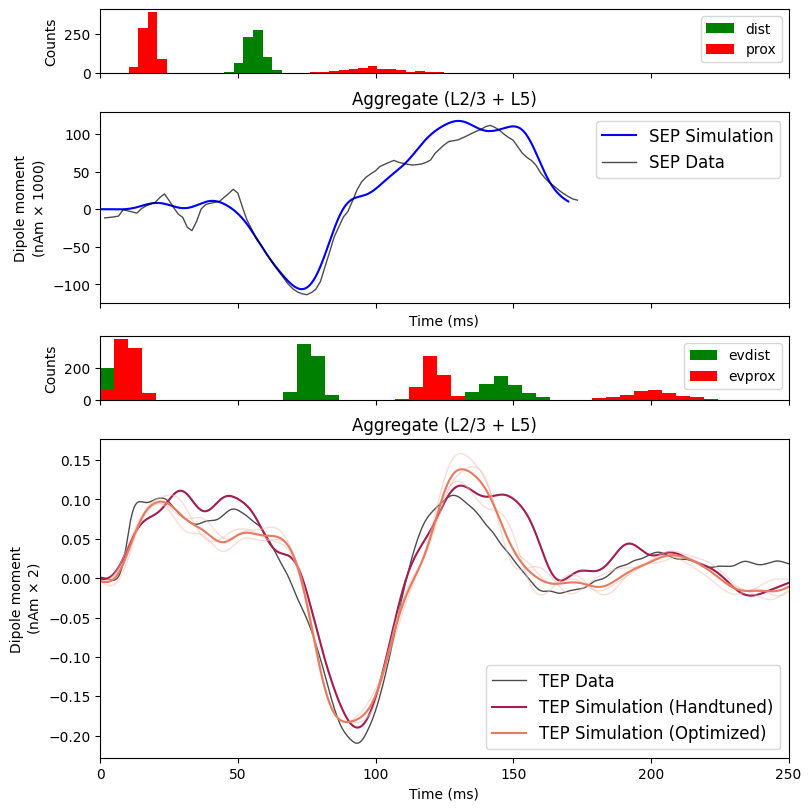

In [14]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 8), constrained_layout=True, height_ratios=[1,3,1,5])
tstop=250
data_scale = 1

# plot 1: SEP drives
SEP_net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['prox','dist'], trial_idx=0, show=False)
axes[0].set_xlim(0,tstop)

# plot 2: dipoles and data
SEP_dpl_smoothed_copy = deepcopy(SEP_dpl_smoothed)
plot_dipole(SEP_dpl_smoothed_copy, ax = axes[1], layer='agg', show=False, average=True,label='SEP Simulation',color='b')
axes[1].plot(np.array(SEP_data[0][:tstop]), np.array(SEP_data[1][:tstop])*data_scale,linewidth=1,color='k', alpha=0.7,label='SEP Data')

axes[1].legend(fontsize=12)
axes[1].set_xlim(0,tstop)

# plot 3: TEP drives
BETA4_net.cell_response.plot_spikes_hist(ax=axes[2], spike_types=['evprox','evdist'], trial_idx=0, show=False)
axes[2].set_xlim(0,tstop)

# Plot 4: TEP simulation
TEP_dpl_smoothed_copy = deepcopy(TEP_dpl_hand_smoothed)
TEP_dpl_optim_smoothed_copy = deepcopy (TEP_dpl_optim_smoothed)

axes[3].plot(np.array(BETA4_data[0][:tstop*10]), np.array(BETA4_data[1][:tstop*10])*data_scale,label='TEP Data',color='k',alpha=0.7,linewidth=1)
plot_dipole(TEP_dpl_smoothed_copy, ax = axes[3], layer='agg', show=False, average=True,label='TEP Simulation (Handtuned)',color='#A41E4F')
plot_dipole(TEP_dpl_optim_smoothed_copy, ax = axes[3], layer='agg', show=False, average=True,label='TEP Simulation (Optimized)',color='#E87A5E')
axes[3].legend(fontsize=12)

plt.savefig('TEP_MBDplot_final_1.png')

TypeError: 'method' object is not subscriptable

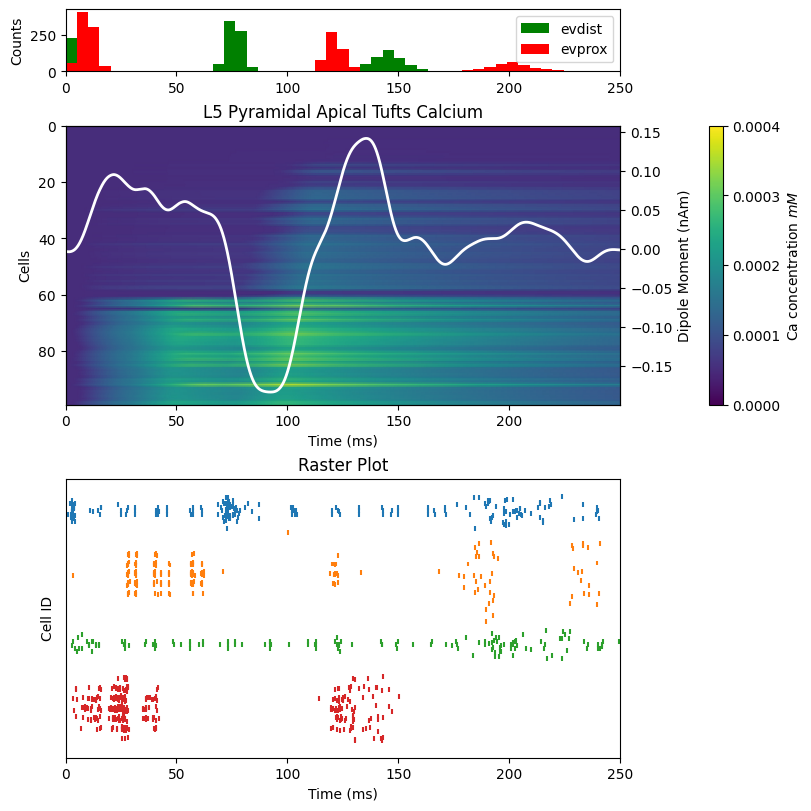

In [19]:
from hnn_core.viz import plot_spikes_raster

fig, axes = plt.subplots(3, 1, sharex=False, figsize=(8, 8), constrained_layout=True, height_ratios=[1,4.5,4.5])
tstop=250
data_scale = 1

TEP_net = BETA4_net_optim
TEP_dpl_optim_smoothed_copy = deepcopy (TEP_dpl_optim_smoothed)

# plot: drives
TEP_net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['evprox','evdist'], trial_idx=0, show=False)

# plot 1: dipole + calcium
# def plot_calcium(net, dpl_smoothed, drive_time, tstop=370, title=None, overlay_spiking=False, spiking_lim=40):

gids = TEP_net.gid_ranges

# find the gids of the neurons that spiked
# l5_gids = gids[np.where(((gids > 169).astype(float) + (gids <=270).astype(float)) == 2)[0]]
l5_gids = gids['L5_pyramidal']
l5_unique_gids = np.array([])
for l5 in l5_gids:
    if ~np.isin(l5,l5_unique_gids):
        l5_unique_gids = np.append(l5_unique_gids, l5)

# get calcium for each cell 
ca_l5_tuft = np.zeros((l5_unique_gids.shape[0], len(TEP_net.cell_response.times)))
ca_l5_apcl2 = np.zeros((l5_unique_gids.shape[0], len(TEP_net.cell_response.times)))
ca_l5_soma = np.zeros((l5_unique_gids.shape[0], len(TEP_net.cell_response.times)))

for i, g in enumerate(l5_unique_gids.astype(int)):
    ca_l5_tuft[i] = TEP_net.cell_response.ca[0][g]['apical_tuft']
    
# sort 
ca_l5_tuft_sort = deepcopy(ca_l5_tuft)

#sorting the cells by their peak concentration time
max_activation_times = [np.argmax(ca_l5_tuft[idx]) for idx in range(len(ca_l5_tuft))]
sort_idx = np.argsort(max_activation_times)
ca_l5_tuft_sort = ca_l5_tuft_sort[sort_idx][::-1, :]

# plot 
timevec = np.arange(0,len(TEP_net.cell_response.times),1)

# calcium concentration
# im = axes[1].pcolormesh(timevec,np.arange(len(l5_unique_gids)),ca_l5_tuft, shading='gouraud',vmin=0, vmax=0.00030)
im = axes[1].pcolormesh(timevec,np.arange(len(l5_unique_gids)),ca_l5_tuft_sort, shading='gouraud',vmin=0, vmax=0.0004)
axes[1].invert_yaxis()
axes[1].set_title('L5 Pyramidal Apical Tufts Calcium')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Cells')

# add colorbar
cb = plt.colorbar(im, ax= axes[1], pad=0.03)
cb.set_ticks([0, 0.0001, 0.0002, 0.0003, 0.0004])
cb.set_label('Ca concentration $mM$')

# # convert x ticks
# axes[1].set_xticks(np.linspace(timevec[0], timevec[-1], 7))
# axes[1].set_xticklabels(np.linspace(0, 320, 7).astype(int))

# Total time in ms and number of points
n_points = len(timevec)  # 14800

# Convert desired tick times (in ms) to indices in timevec
tick_times = np.arange(0, tstop-20+1, 50)  # 0, 50, ..., 300
tick_indices = (tick_times / tstop * n_points).astype(int)

# Set ticks and labels
axes[1].set_xticks(tick_indices)
axes[1].set_xticklabels(tick_times)
axes[1].set_xlim(0, n_points)
ax2 = axes[1].twinx()


# plot the dipole
TEP_dpl_optim_smoothed_copy = deepcopy (TEP_dpl_optim_smoothed)
ax2.plot(timevec,TEP_dpl_optim_smoothed_copy[0].data['agg'], color=(1,1,1), linewidth = 2)
ax2.set_ylabel('Dipole Moment (nAm)')


# plot 5: spiking 
plot_spikes_raster(TEP_net.cell_response, ax=axes[2],trial_idx=None, show=False, show_legend=False, marker_size=5)
axes[2].set_xlim(0,250)
axes[2].set_title['Spiking Raster']

plt.savefig('TEP_MBDplot_final_2.png')